### Top 20 Models - 4 Class ANN Comparison


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('default')
sns.set_palette("husl")

RESULTS_DIR = Path("results/4_Classes_ANN")
results_csv = RESULTS_DIR / "all_experiments.csv"

df = pd.read_csv(results_csv)
print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

Total experiments: 225
Columns: ['experiment_id', 'architecture', 'hidden1', 'hidden2', 'weight_decay', 'dropout_rate', 'pca_components', 'learning_rate', 'mean_accuracy', 'std_accuracy', 'macro_sensitivity', 'macro_specificity', 'macro_precision', 'macro_f1', 'weighted_sensitivity', 'weighted_specificity', 'weighted_precision', 'weighted_f1', 'per_class_sensitivity', 'per_class_specificity', 'per_class_precision', 'per_class_f1', 'total_epochs', 'training_time_s', 'model_file', 'confusion_matrix_file']

First 5 rows:
   experiment_id architecture  hidden1  hidden2  weight_decay  dropout_rate  \
0              1      1-layer       16      NaN           0.2           0.5   
1              2      1-layer       16      NaN           0.2           0.6   
2              3      1-layer       16      NaN           0.2           0.7   
3              4      1-layer       16      NaN           0.3           0.5   
4              5      1-layer       16      NaN           0.3           0.6   

 

In [2]:
print("="*80)
print("EXPERIMENT SUMMARY")
print("="*80)
print(f"\nTotal experiments: {len(df)}")
print(f"Best accuracy:  {df['mean_accuracy'].max()*100:.2f}%")
print(f"Worst accuracy: {df['mean_accuracy'].min()*100:.2f}%")
print(f"Mean accuracy:  {df['mean_accuracy'].mean()*100:.2f}%")
print(f"Median accuracy: {df['mean_accuracy'].median()*100:.2f}%")

print(f"\nBest macro sensitivity:  {df['macro_sensitivity'].max():.4f}")
print(f"Best macro specificity:  {df['macro_specificity'].max():.4f}")
print(f"Mean macro sensitivity:  {df['macro_sensitivity'].mean():.4f}")
print(f"Mean macro specificity:  {df['macro_specificity'].mean():.4f}")


EXPERIMENT SUMMARY

Total experiments: 225
Best accuracy:  34.38%
Worst accuracy: 15.62%
Mean accuracy:  24.79%
Median accuracy: 25.00%

Best macro sensitivity:  0.3118
Best macro specificity:  0.7693
Mean macro sensitivity:  0.2465
Mean macro specificity:  0.7497


In [3]:
df_sorted = df.sort_values('mean_accuracy', ascending=False)

print("\n" + "="*120)
print("TOP 15 MODELS")
print("="*120)

top15 = df_sorted.head(15)

for i, (idx, model) in enumerate(top15.iterrows(), 1):
    print(f"\n#{i} - Experiment {model['experiment_id']}")
    print(f"  Architecture: {model['architecture']}")
    print(f"  Hidden Layers: {model['hidden1']}" + (f" -> {model['hidden2']}" if model['hidden2'] != 'None' else ""))
    
    pca_str = f", PCA: {model['pca_components']}" if 'pca_components' in model and model['pca_components'] != 'None' else ""
    print(f"  Hyperparameters: Weight Decay={model['weight_decay']}, Dropout={model['dropout_rate']}{pca_str}")
    print(f"  Accuracy: {model['mean_accuracy']*100:.2f}% +/- {model['std_accuracy']*100:.2f}%")
    print(f"  Macro Sensitivity: {model['macro_sensitivity']:.4f}, Macro Specificity: {model['macro_specificity']:.4f}")
    print(f"  Macro Precision: {model['macro_precision']:.4f}, Macro F1: {model['macro_f1']:.4f}")
    print(f"  Weighted Sensitivity: {model['weighted_sensitivity']:.4f}, Weighted Specificity: {model['weighted_specificity']:.4f}")
    print(f"  Training: {model['total_epochs']} epochs, {model['training_time_s']:.1f}s")
    print(f"  Model File: {model['model_file']}")

print("\n" + "="*120)



TOP 15 MODELS

#1 - Experiment 163
  Architecture: 2-layer-PCA20
  Hidden Layers: 8 -> 4.0
  Hyperparameters: Weight Decay=0.2, Dropout=0.5, PCA: 20.0
  Accuracy: 34.38% +/- 8.90%
  Macro Sensitivity: 0.2738, Macro Specificity: 0.7654
  Macro Precision: 0.2518, Macro F1: 0.2014
  Weighted Sensitivity: 0.3438, Weighted Specificity: 0.7177
  Training: 873 epochs, 6.3s
  Model File: model_h8-4_wd0.2_dr0.5_pca20.pt

#2 - Experiment 10
  Architecture: 1-layer
  Hidden Layers: 8 -> nan
  Hyperparameters: Weight Decay=0.2, Dropout=0.5, PCA: nan
  Accuracy: 33.75% +/- 8.39%
  Macro Sensitivity: 0.3118, Macro Specificity: 0.7693
  Macro Precision: 0.1953, Macro F1: 0.2204
  Weighted Sensitivity: 0.3375, Weighted Specificity: 0.7398
  Training: 1300 epochs, 10.6s
  Model File: model_h8_wd0.2_dr0.5.pt

#3 - Experiment 26
  Architecture: 2-layer
  Hidden Layers: 32 -> 16.0
  Hyperparameters: Weight Decay=0.5, Dropout=0.6, PCA: nan
  Accuracy: 33.75% +/- 2.17%
  Macro Sensitivity: 0.2563, Macro Sp

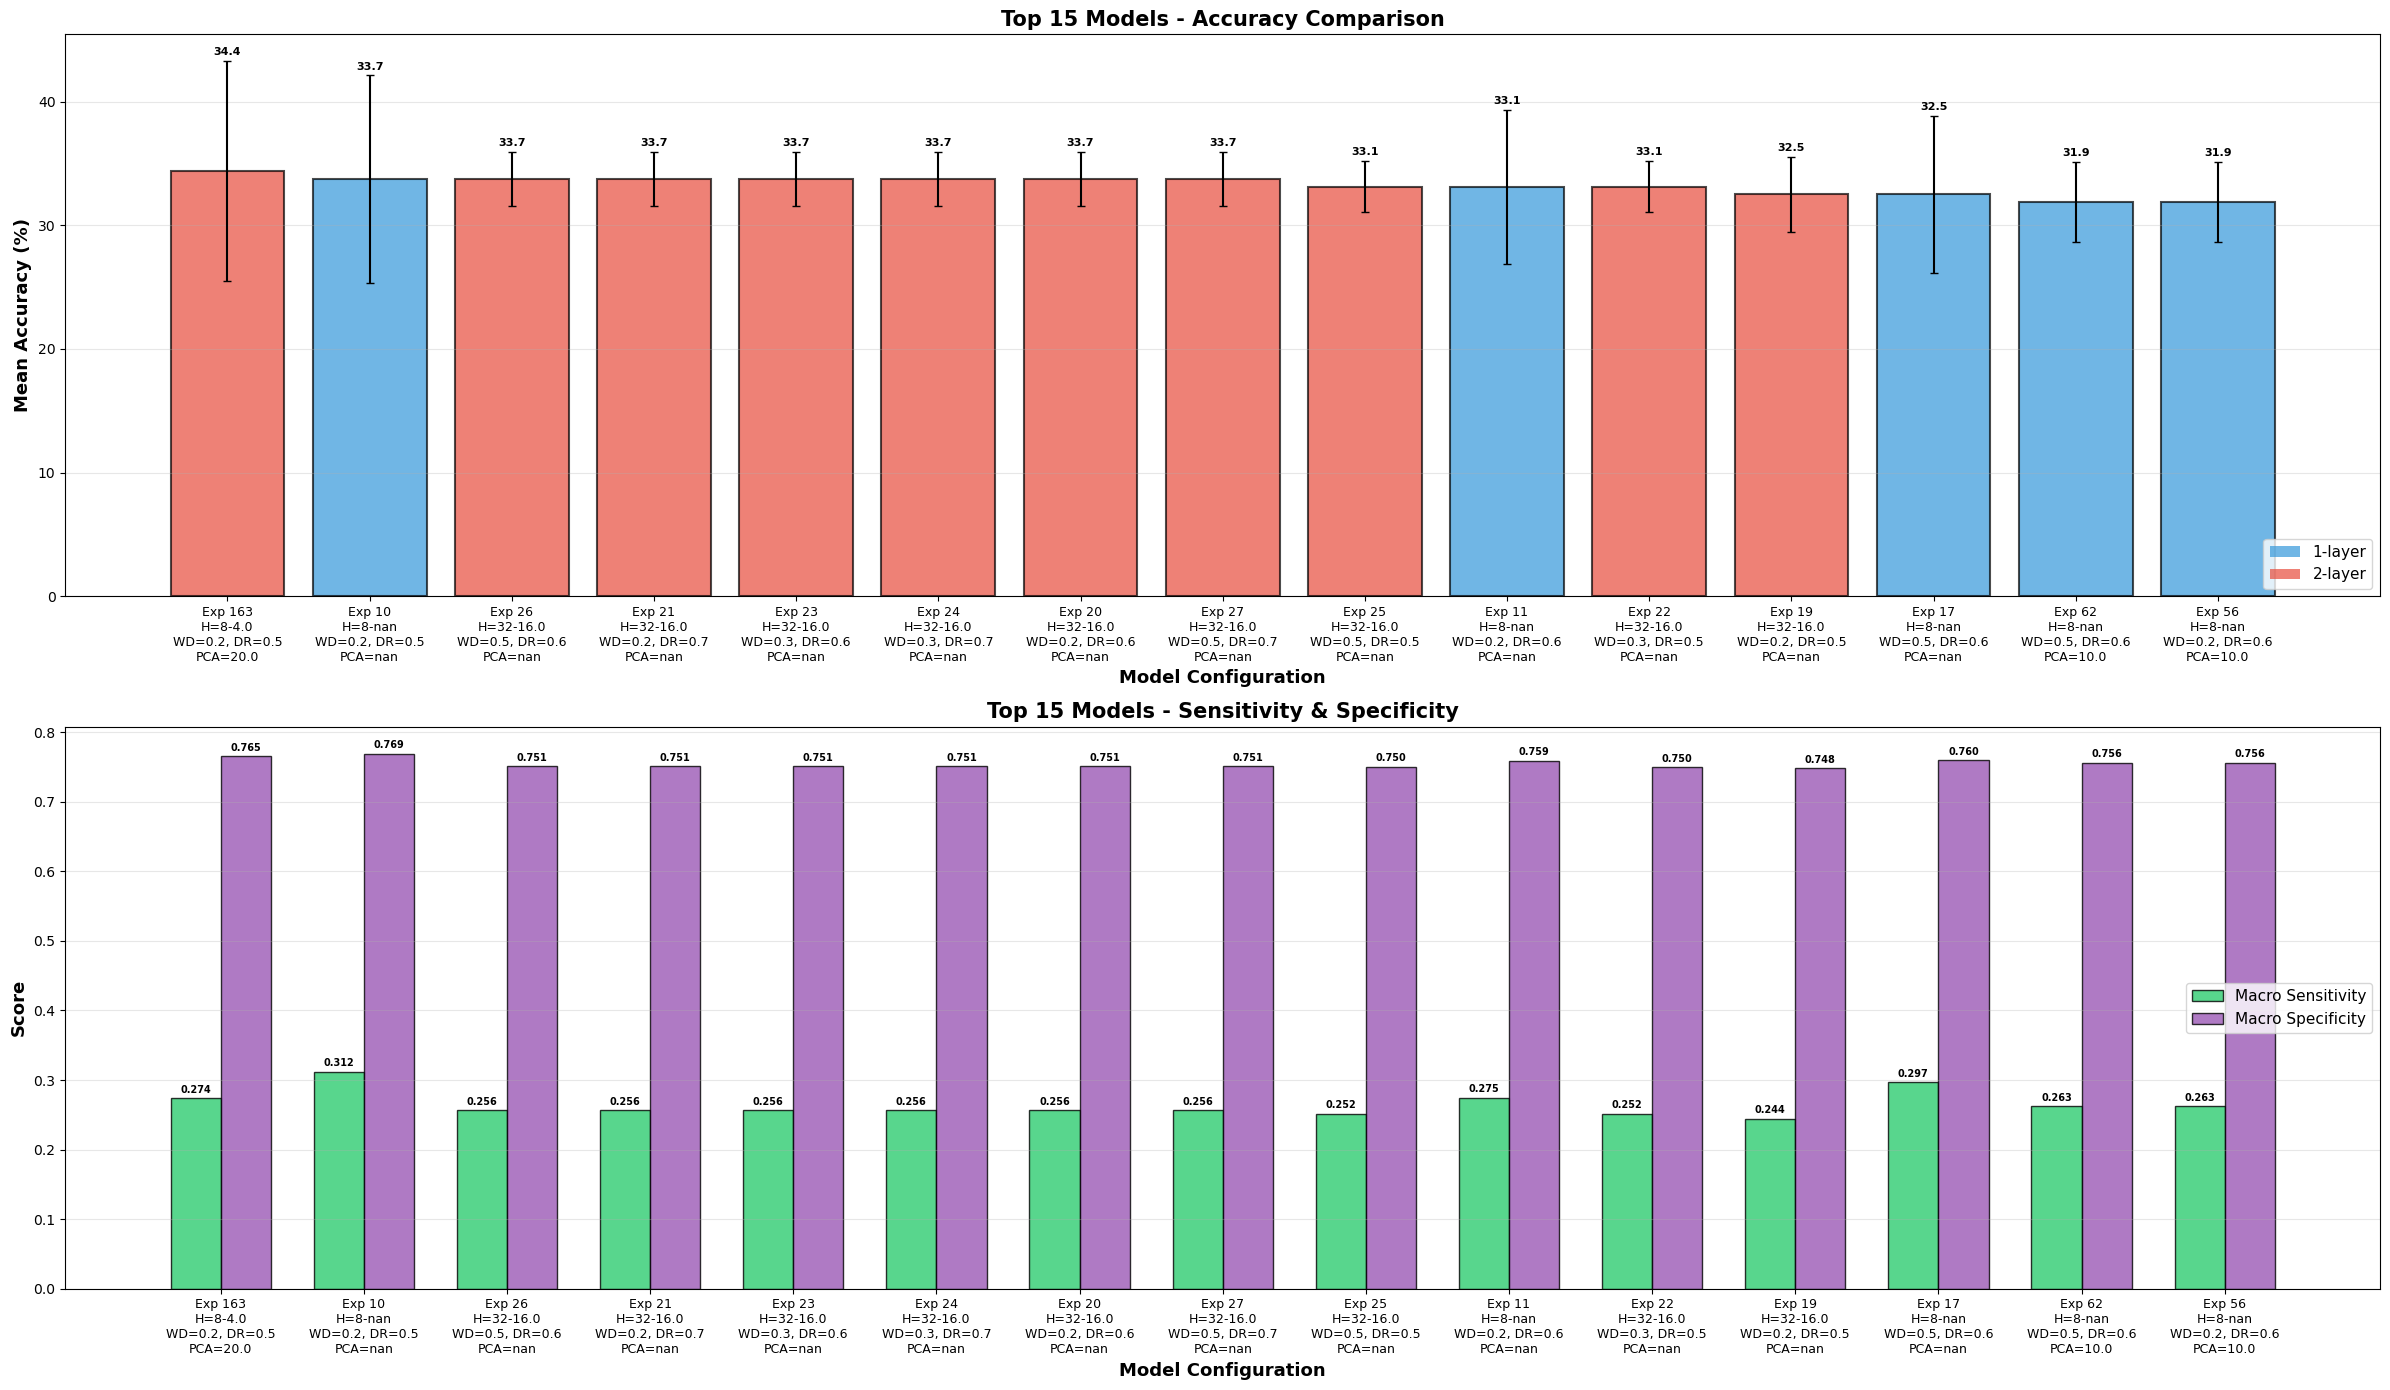

Top 15 models plot saved to: results\4_Classes_ANN\figures\top15_models.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(24, 14))

top15 = df_sorted.head(15)
model_labels = []
accuracies = []
errors = []
sensitivities = []
specificities = []
colors = []

for idx, model in top15.iterrows():
    hidden_str = f"H={model['hidden1']}" if model['hidden2'] == 'None' else f"H={model['hidden1']}-{model['hidden2']}"
    pca_str = f"\nPCA={model['pca_components']}" if 'pca_components' in model and model['pca_components'] != 'None' else ""
    label = f"Exp {model['experiment_id']}\n{hidden_str}\nWD={model['weight_decay']}, DR={model['dropout_rate']}{pca_str}"
    model_labels.append(label)
    accuracies.append(model['mean_accuracy'] * 100)
    errors.append(model['std_accuracy'] * 100)
    sensitivities.append(model['macro_sensitivity'])
    specificities.append(model['macro_specificity'])
    
    if '1-layer' in model['architecture']:
        colors.append('#3498db')
    else:
        colors.append('#e74c3c')

bars = axes[0].bar(range(len(model_labels)), accuracies, yerr=errors, capsize=3, 
              color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

axes[0].set_xticks(range(len(model_labels)))
axes[0].set_xticklabels(model_labels, fontsize=9, rotation=0, ha='center')
axes[0].set_ylabel('Mean Accuracy (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Model Configuration', fontsize=13, fontweight='bold')
axes[0].set_title('Top 15 Models - Accuracy Comparison', fontsize=15, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

for i, (bar, acc, err) in enumerate(zip(bars, accuracies, errors)):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + err + 0.3,
            f'{acc:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[0].legend([plt.Rectangle((0,0),1,1, fc='#3498db', alpha=0.7),
           plt.Rectangle((0,0),1,1, fc='#e74c3c', alpha=0.7)],
          ['1-layer', '2-layer'], loc='lower right', fontsize=11)

x = range(len(model_labels))
width = 0.35

bars1 = axes[1].bar([i - width/2 for i in x], sensitivities, width, 
                    label='Macro Sensitivity', color='#2ecc71', alpha=0.8, edgecolor='black')
bars2 = axes[1].bar([i + width/2 for i in x], specificities, width,
                    label='Macro Specificity', color='#9b59b6', alpha=0.8, edgecolor='black')

axes[1].set_xticks(x)
axes[1].set_xticklabels(model_labels, fontsize=9, rotation=0, ha='center')
axes[1].set_ylabel('Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Model Configuration', fontsize=13, fontweight='bold')
axes[1].set_title('Top 15 Models - Sensitivity & Specificity', fontsize=15, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{height:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{height:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'top15_models.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Top 15 models plot saved to: {RESULTS_DIR / 'figures' / 'top15_models.png'}")


In [5]:
top15_df = df_sorted.head(15)[['experiment_id', 'architecture', 'hidden1', 'hidden2', 
                               'weight_decay', 'dropout_rate', 'pca_components', 
                               'mean_accuracy', 'std_accuracy', 
                               'macro_sensitivity', 'macro_specificity', 'macro_precision', 'macro_f1',
                               'weighted_sensitivity', 'weighted_specificity', 'weighted_precision', 'weighted_f1',
                               'per_class_sensitivity', 'per_class_specificity', 'per_class_precision', 'per_class_f1',
                               'total_epochs', 'training_time_s', 'model_file', 'confusion_matrix_file']]

top15_df.to_csv(RESULTS_DIR / 'top15_models.csv', index=False)

print(f"\nTop 15 models saved to: {RESULTS_DIR / 'top15_models.csv'}")
print(f"All done!")



Top 15 models saved to: results\4_Classes_ANN\top15_models.csv
All done!
